# Gaussian quadrature

Up until this point, we have been using techniques for which the data points are fixed, (hopefully) evenly spaced, and at the limits of our subdomains. When we do, we get expressions of the form, 

$$
I = c_0 f(x_0) + c_1 f(x_1) +c_2 f(x_2) \dots
$$

where the $c_i$ are constants and the $x_i$ are evenly spaced. Higher order accuracy is obtained by approximating higher order derivatives (Newton-Cotes) or successive iterations to approximate and cancel error (Romberg). 

Gaussian quadrature assumes you are free to choose the $x_i$. The goal is then to find special sets of $x_i$ (called Gauss points) for which the integral is obtained most efficiently. 

## The 2-point Gauss-Legendre formula

Lets poropose a formula for the integral of a function $f(x)$ in the range [-1,1], 

$$ I = \int_{-1}^1 f(x) dx \approx c_0 f(x_0) + c_1 f(x_1) $$

where $c_0$, $c_1$, $x_0$, and $x_1$ are unknowns. Since we have 4 unknows, we require 4 conditions to determine them. Lets *require* that the above formula is *exact* for polynomials up to cubics. Our four equations can be obtained from the monomials up to order 3 (which form a set of basis functions for cubics):

$$ \begin{align}
f(x) = x^0 &\rightarrow c_0 + c_1 &= \int_{-1}^1 1 dx  &= 2 \\
f(x) = x^1 &\rightarrow c_0 x_0 + c_1 x_1 &= \int_{-1}^1 x dx  &= 0 \\
f(x) = x^2 &\rightarrow c_0 x_0^2 + c_1 x_1^2 &= \int_{-1}^1 x^2 dx  &= \frac{2}{3} \\
f(x) = x^3 &\rightarrow c_0 x_0^3 + c_1 x_1^3 &= \int_{-1}^1 x^3 dx  &= 0 \\
\end{align} $$

which is a nonlinear system of equations which can be solved to find, 

$$ \begin{align}
c_0 &= c_1 = 1 \\
x_0 &= -\frac{1}{\sqrt{3}}\\
x_1 &= \frac{1}{\sqrt{3}}
\end{align} $$

Therefore:

$$ I = f\bigg(\frac{-1}{\sqrt{3}}\bigg)+f\bigg(\frac{1}{\sqrt{3}}\bigg) $$

That is a remarkable result! A cubic function can be integrated **exactly** meerly through the sum of the function evaluated at 2 points?!?

In [1]:
import numpy as np

def two_point_gaussian_quadrature(f):
  #Calculates the integral of a function between -1 and 1 using 2-point Gaussian quadrature.
  return f(-1 / np.sqrt(3)) + f(1 / np.sqrt(3))

import sympy as sp

x = sp.var('x')

def quad_tester(f):
  fcn = sp.lambdify(x, f)
  fI = sp.integrate(f, (x, -1, 1))
  print('Function ', f, ' Integral is ', fI, ' error ', two_point_gaussian_quadrature(fcn)-fI)

quad_tester( x**2)
quad_tester( x**3-x**2+np.pi*x+17)
quad_tester( -10**9* x**3 + np.exp(8.314)*x**2 - np.pi**.5*x + 42)

Function  x**2  Integral is  2/3  error  2.22044604925031e-16
Function  x**3 - x**2 + 3.14159265358979*x + 17  Integral is  33.3333333333333  error  0
Function  -1000000000*x**3 + 4080.60279354035*x**2 - 1.77245385090552*x + 42  Integral is  2804.40186238289  error  0


#### Transformation to an arbitrary domain

The preceeding case specified the integration limits as [-1,1]. To apply Gaussian quadrature to an arbitrary integration limits $[a,b]$ we simply do a coordinate transformation:

$$ x = a_0 + a_1 x_d$$

at the limits,

$$\begin{align}
a &= a_0 + a_1 (-1) \\
b &= a_0 + a_1 (1)
\end{align}$$

Such that,

$$\begin{align}
a_0 &= \frac{b+a}{2}\\
a_1 &= \frac{b-a}{2}
\end{align}$$

and therefore,

$$ x = \frac{[b+a] + [b-a] x_d}{2}$$
and

$$ dx = \frac{b-a}{2} dx_d$$

which can be inserted into the integrand function at which point to make a new function in the form Gaussian Quadrature expects.


In [ ]:
def flex_gq(f, a, b):
  x0 = (-1 / np.sqrt(3))
  x1 = (1 / np.sqrt(3))

  x_d0 = ((b + a) + (b - a) * x0) / 2
  x_d1 = ((b + a) + (b - a) * x1) / 2
  dx = (b - a) / 2

  return (f(x_d0) + f(x_d1))*dx

def flex_gq_tester(f, a, b):
  fcn = sp.lambdify(x, f)
  fI = sp.integrate(f, (x, a, b))
  print('Function ', f, ' Integral is ', fI, ' error ', flex_gq(fcn,a,b)-fI)

flex_gq_tester( x**2, 0, 1)
flex_gq_tester( x**3-x**2+np.pi*x+17, 0, 1)

Function  x**2  Integral is  1/3  error  0
Function  x**3 - x**2 + 3.14159265358979*x + 17  Integral is  18.4874629934616  error  -3.55271367880050e-15


Jinkies!

## The n-point Gauss-Legendre formula

The method may be generalized to higher-point problems that will find higher degree polynomials exactly.

$$
I = \sum_i c_i f(x_i)
$$ 

with $c_i$ given in the table below:


| Integration order | Coefficient (ci) | Gauss Point (xi) | Error |
|---|---|---|---|
| 2 | 1 | $\pm \frac{1}{\sqrt{3}}$ | $f^{(4)}$ |
| 3 | $\frac{8}{9}$ | $0$ | $f^{(6)}$ |
|   | $\frac{5}{9}$ | $\pm \frac{3}{5}$ |
| 4 | $\frac{18 \pm \sqrt{30}}{36}$ | $\pm\sqrt{\frac{3}{7} \pm \frac{2}{7}\sqrt{\frac{6}{5}}}$ | $f^{(8)}$ |
$\vdots$

#### Error

Note that the error is given in terms of a derivative of $f$, since the step size is no longer an issue. In general, the error is,

$$Error = \frac{2^{2n+1} [n+1]!^4}{[2n+3][2n+2]!^3} f^(2n+2)(ξ)$$

i.e.: proportional to the $[2n+2]th$ derivative evaluated at some point ξ in $[-1,1]$.

## N-D Gauss-Legendre quadrature

Due to the separable nature of N-D integration, extension of this concept to N-D is an exercise in repeated application to determine coefficients and Gauss-points on some standard N-D interval.

### Quadrilateral elements

Consider the double integral,

$$ 
\int_{-1}^{1} \int_{-1}^{1} f(\alpha, \beta) d\alpha d\beta = \int_{-1}^{1} \bigg[\int_{-1}^{1} f(\alpha, \beta) d\alpha \bigg] d\beta
$$

which can now be broken down into repeated applications of 1D integration.

We will need to transform the original quadrilateral into our standard range, for which we use:

$$\begin{align}
x(\alpha,\beta) &= \sum_{k=1}^4 N_k(\alpha,\beta)x_k \\
y(\alpha,\beta) &= \sum_{k=1}^4 N_k(\alpha,\beta)y_k
\end{align}$$

where $<x_k, y_k>$ are the coordinates of hte corners of the quadralateral, and the *shape functions* are,

$$\begin{align}
N_1(\alpha, \beta) = \frac{1}{4}[1-\alpha][1-\beta] \\
N_2(\alpha, \beta) = \frac{1}{4}[1+\alpha][1-\beta] \\
N_3(\alpha, \beta) = \frac{1}{4}[1+\alpha][1+\beta] \\
N_4(\alpha, \beta) = \frac{1}{4}[1-\alpha][1+\beta] \\
\end{align}$$

Note the shape functions are *bilinear* (linear in each coordinate) such that straight lines remain straight upon mapping.

The mapping distorts the area of the quadrilateral,

$$ dx dy = \bigg\| \frac{\partial <x,y>} {\partial <\alpha, \beta>} \bigg\| d\alpha d\beta$$
which can be derived from the relations above.

An example of a quadralateral with a 3rd integration order is below showing the mapping between computational coordinates (left) and *real* coordinates (right). Gauss points are given in circles.

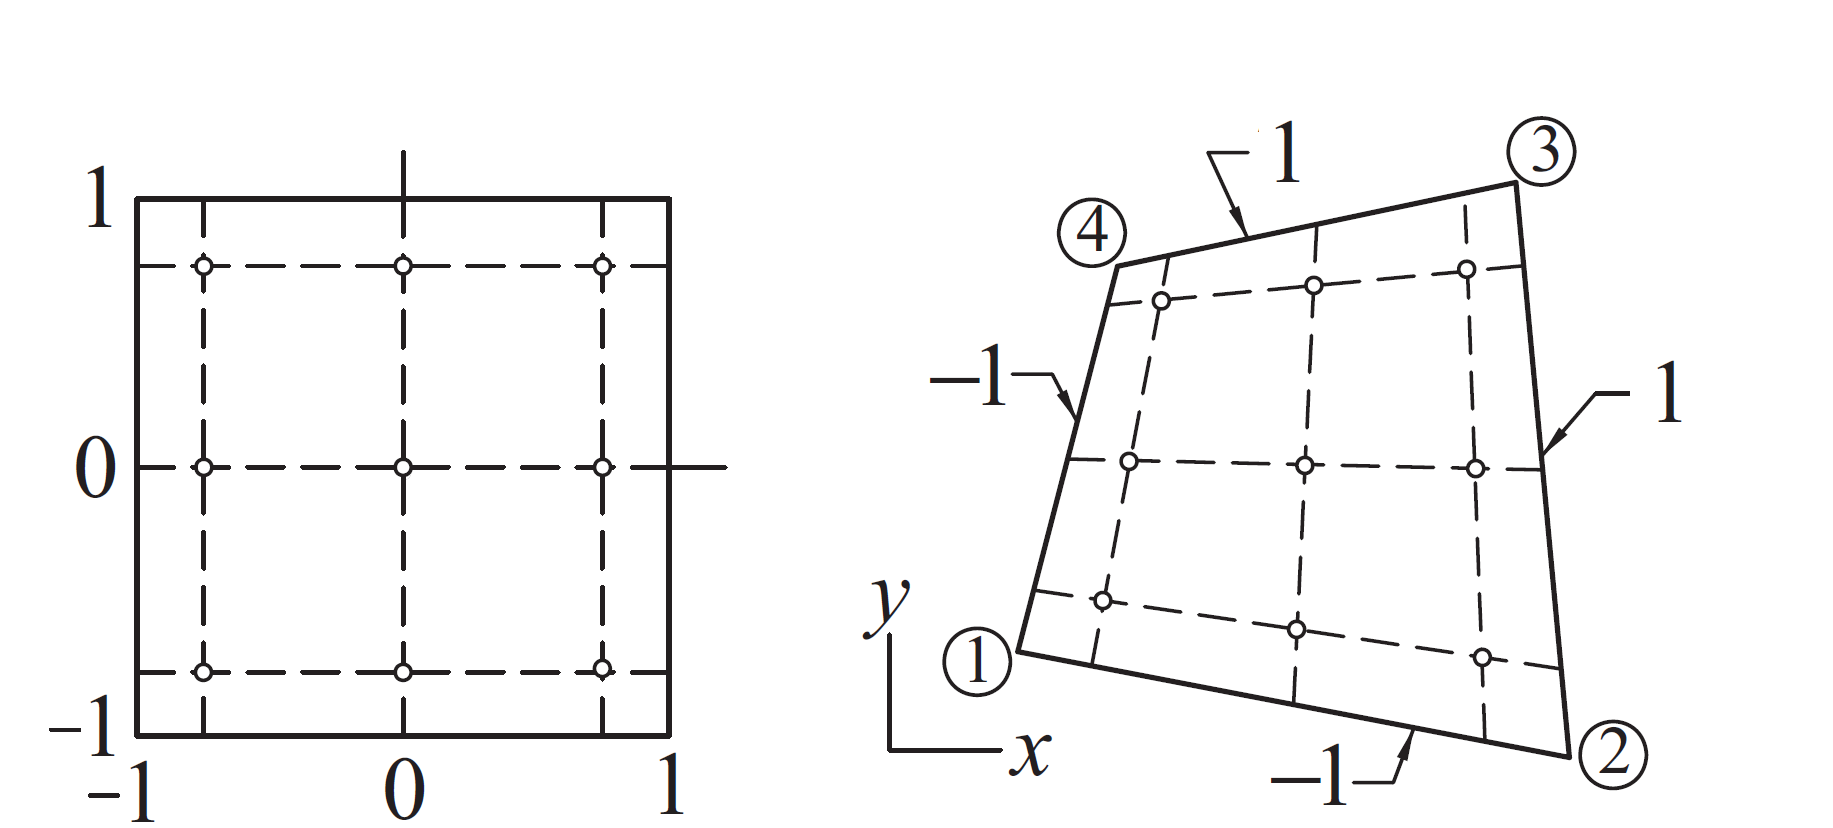

### Triangular elements

In some irregular domains, a quadralateral may be forced to reduce a side length to zero, thereby becoming degenerate quadralateral, or simply a triangle. Since the former can always be divided into two triangles, it is sensible to consider quadrature on a triangle.

In fact, since triangles are the 2D simplex they are able to fill any shape and are typically the go-to for tesselation (space-filling tiling).  

Consider dividing a triangle into 3 parts connecting the verticies with a point P,

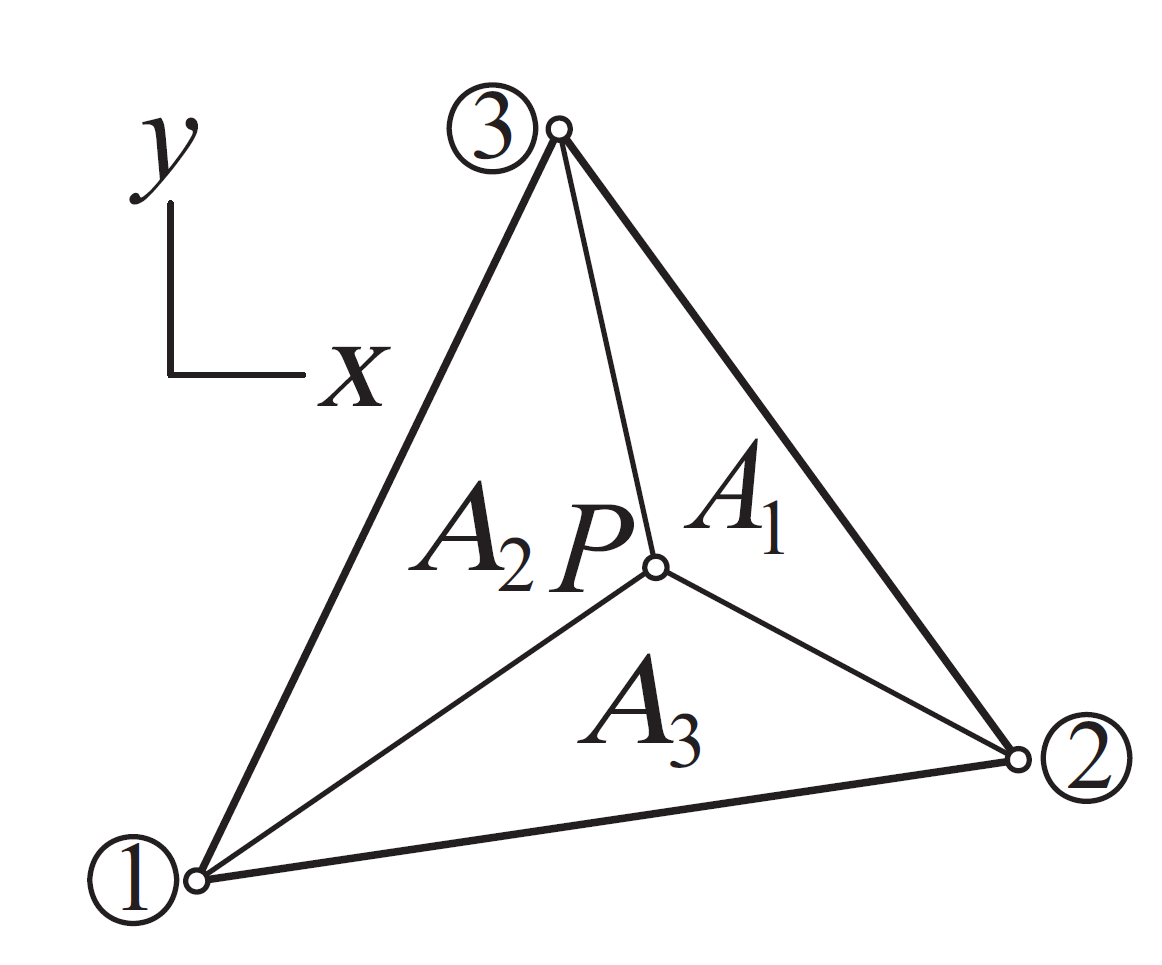

so as to define areas $A_{1,2,3}$. The *area coordinates* of P are,

$$
\alpha_i = \frac{A_i}{A}
$$

and since $A_1+A_2+A_3 = A$,

$$
\alpha_1 +\alpha_2+\alpha_3 = 1
$$
.

Note that $\alpha_i$ ranges from 0 to 1 when P moves from the opposing side to the corner $i$.

Using these coordinates,

$$\begin{align}
x(\alpha_1, \alpha_2, \alpha_3) = \sum_{i=1}^3 \alpha_i x_i \\
y(\alpha_1, \alpha_2, \alpha_3) = \sum_{i=1}^3 \alpha_i y_i \\
\end{align} $$

and the integration becomes,

$$
\int \int_A f(x,y) dA = A \sum_k W_k f\big(x(\alpha_k), y(\alpha_k)\big) 
$$

with the area,

$$A = \frac{1}{2} \begin{vmatrix}
1 &1 &1 \\
x_1& x_2& x_3 \\
y_1& y_2& y_3
\end{vmatrix}$$

The weights $W_k$ are given by,

| Order (n) | Point | Weight ($W_k$) | Area Coordinates ($\alpha_1$, $\alpha_2$, $\alpha_3$) |
|---|---|---|---|
| Linear | a|  1.0 | (1/3, 1/3, 1/3) |
| Quadratic |a | 1/3 | (1/2, 0, 1/2) |
|  |b| 1/3 | (1/2, 1/2,0) |
|  |c| 1/3 | (0, 1/2, 1/2) |
| Cubic | a| -27/48 | (1/3, 1/3, 1/3) |
|  |b| 25/48 | (1/5, 1/5, 3/5) |
|  |c| 25/48 | (3/5, 1/5, 1/5) |
|  |d| 25/48 | (1/5, 3/5, 1/5) |







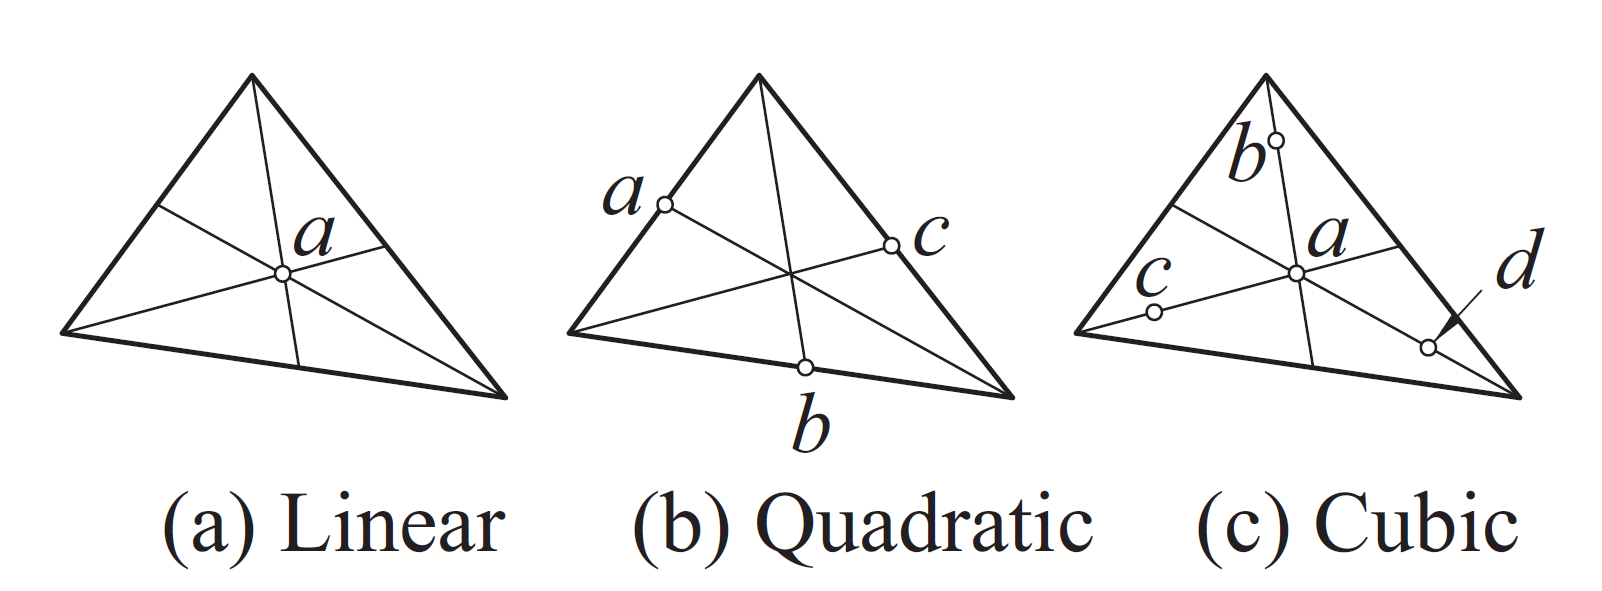